# MLForecast with synthetic data

This guide compares an observed-data baseline, global training with observed and augmented series, and models trained only on independent synthetic series and transferred zero-shot to the observed series.


MLForecast trains a single global model over lagged and derived features pooled across every series in the panel. Because that fitted estimator is shared, two things follow. Adding synthetic series changes the model the observed series is scored by — unlike a local model fitted independently per series, where extra series leave the target fit untouched. And a model trained only on synthetic series can be applied to a previously unseen panel through `predict(new_df=...)`, which is zero-shot transfer rather than a per-series refit. Both workflows below rely on that shared-weight behavior.

::: {.callout-important}
## Scale the target before pooling series

A global model sees every series through one set of coefficients, so series on different levels have to be made comparable first. The forecaster below applies `Differences([12])` to remove the annual seasonal trend and `LocalStandardScaler()` to put each series on its own scale.

Without those transforms every synthetic workflow on this page degrades by a factor of four to six: the estimator fits whatever level the synthetic panel happens to occupy and predicts a nearly flat line for the airline series. That failure is a symptom of the model configuration, not of the synthetic data.
:::


We use the classic [Box–Jenkins airline passenger series](https://search.r-project.org/R/refmans/datasets/html/AirPassengers.html), holding out its final 12 months before generating any augmented data.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences, LocalStandardScaler
from sklearn.linear_model import Ridge

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae

from synforecast import SynAugment, SynSet, generate_series
from synforecast.generators import ETSGenerator, SARIMAGenerator, SeasonalGenerator


In [ ]:
HORIZON = 12
TARGET_ID = "AirPassengers"
data_path = Path("nbs/data/air_passengers.csv")
if not data_path.exists():
    data_path = Path("../../data/air_passengers.csv")

observed_df = pd.read_csv(data_path, parse_dates=["ds"])
train_df = observed_df.iloc[:-HORIZON].copy()
test_df = observed_df.iloc[-HORIZON:].copy()
train_df.tail()

,unique_id,ds,y
127,AirPassengers,1959-08-31,559.0
128,AirPassengers,1959-09-30,463.0
129,AirPassengers,1959-10-31,407.0
130,AirPassengers,1959-11-30,362.0
131,AirPassengers,1959-12-31,405.0


The next cell builds the four training sets. The observed baseline is the single airline series. The augmented panel adds eight counterparts of that series, drawn with `SynAugment` under a SARIMA override so the generated histories match its seasonal structure; the 12-month holdout is removed first, so no future value reaches the augmenter.

The two pretraining panels are both independent of the airline data, and differ only in how they were composed:

- **matched monthly pool** — SARIMA, ETS, and seasonal generators configured for monthly data with a 12-step seasonal period, an upward trend, and a comparable level.
- **generic balanced pool** — `generate_series` with its defaults, which spans random walks, volatility clustering, chaos, and counts at whatever scale each process produces.

Non-finite synthetic series are dropped from both so the estimator trains on clean histories.


In [ ]:
augmented_train_df = SynAugment(seed=42).augment(
    train_df,
    n_augment=8,
    generator_override={TARGET_ID: "SARIMAGenerator"},
)

n_obs = len(train_df)
monthly_generators = [
    SARIMAGenerator(
        min_length=n_obs, max_length=n_obs, freq="ME", engine="polars",
        seasonal_period=12, d=1, D=1, noise_std=2.0, seed=seed,
    )
    for seed in range(4)
] + [
    ETSGenerator(
        min_length=n_obs, max_length=n_obs, freq="ME", engine="polars",
        seasonal_period=12, trend_type="add", seasonal_type="add",
        level=300.0, trend=1.5, seed=10 + seed,
    )
    for seed in range(4)
] + [
    SeasonalGenerator(
        min_length=n_obs, max_length=n_obs, freq="ME", engine="polars",
        seasonality_period=12, base_level=300.0, trend=1.5,
        seasonality_amplitude=50.0, noise_level=10.0, seed=20 + seed,
    )
    for seed in range(4)
]


def drop_non_finite(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only series whose values are all finite."""
    finite = df.groupby("unique_id", observed=True)["y"].apply(
        lambda values: np.isfinite(values).all()
    )
    return df.loc[df["unique_id"].isin(finite[finite].index)].copy()


# The generators emit Polars; the rest of this guide stays on pandas.
matched_pretrain_df = drop_non_finite(
    SynSet(monthly_generators).generate(n_series_per_generator=3).to_pandas()
)
generic_pretrain_df = drop_non_finite(
    generate_series(
        n_series=32, freq="ME", min_length=n_obs, max_length=n_obs, seed=42
    )
)

pd.DataFrame(
    {
        "training set": [
            "observed only",
            "observed + augmented",
            "matched monthly pool",
            "generic balanced pool",
        ],
        "series": [
            1,
            augmented_train_df["unique_id"].nunique(),
            matched_pretrain_df["unique_id"].nunique(),
            generic_pretrain_df["unique_id"].nunique(),
        ],
    }
)


,training set,series
0,observed only,1
1,observed + augmented,9
2,matched monthly pool,36
3,generic balanced pool,32


In [ ]:
def make_forecaster() -> MLForecast:
    return MLForecast(
        models=Ridge(alpha=1.0),
        freq="ME",
        lags=[1, 2, 3, 6, 12],
        target_transforms=[Differences([12]), LocalStandardScaler()],
    )


def target_forecast(forecast_df: pd.DataFrame) -> pd.DataFrame:
    return forecast_df.loc[
        forecast_df["unique_id"].astype(str) == TARGET_ID,
        ["unique_id", "ds", "Ridge"],
    ].copy()


In [ ]:
real_only = make_forecaster()
real_only.fit(train_df)
real_only_forecast = target_forecast(real_only.predict(h=HORIZON))

In [ ]:
with_augmentation = make_forecaster()
with_augmentation.fit(augmented_train_df)
augmented_forecast = target_forecast(with_augmentation.predict(h=HORIZON))

MLForecast can apply a fitted global estimator to unseen series through `predict(new_df=...)`. The estimators below are fitted only on independent SynForecast series; the observed history is supplied only when producing its recursive lag features and forecasts. This is zero-shot transfer, not fine-tuning.

Fitting both pools separately is what makes the comparison useful: the pretraining corpus is a modeling choice, and choosing it badly costs more accuracy here than skipping pretraining altogether.


In [ ]:
matched_pretrained = make_forecaster()
matched_pretrained.fit(matched_pretrain_df)
matched_zero_shot_forecast = target_forecast(
    matched_pretrained.predict(h=HORIZON, new_df=train_df)
)

generic_pretrained = make_forecaster()
generic_pretrained.fit(generic_pretrain_df)
generic_zero_shot_forecast = target_forecast(
    generic_pretrained.predict(h=HORIZON, new_df=train_df)
)


We score each workflow by mean absolute error over the 12-month holdout for the airline series.

In [ ]:
forecast_sets = {
    "Observed only": real_only_forecast,
    "Observed + augmented": augmented_forecast,
    "Zero-shot, matched pool": matched_zero_shot_forecast,
    "Zero-shot, generic pool": generic_zero_shot_forecast,
}
comparison = test_df[["unique_id", "ds", "y"]].copy()
for label, forecast_df in forecast_sets.items():
    comparison = comparison.merge(
        forecast_df.rename(columns={"Ridge": label}),
        on=["unique_id", "ds"],
        how="left",
    )

scores = evaluate(comparison, metrics=[mae], models=list(forecast_sets))
metrics = (
    scores.melt(id_vars=["unique_id", "metric"], var_name="workflow", value_name="MAE")
    .loc[:, ["workflow", "MAE"]]
    .sort_values("MAE", ignore_index=True)
)
metrics

,workflow,MAE
0,"Zero-shot, matched pool",12.507531
1,Observed + augmented,14.613678
2,Observed only,16.302282
3,"Zero-shot, generic pool",22.675395


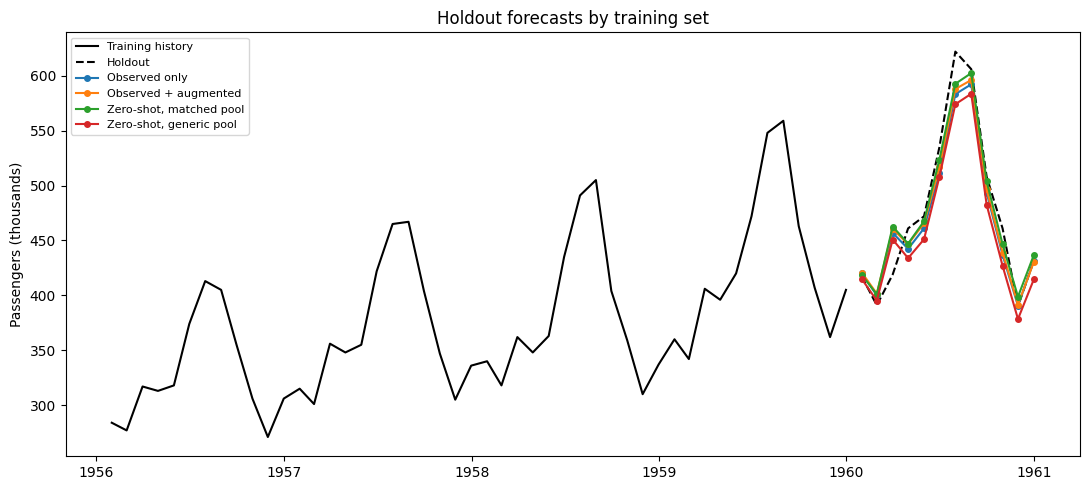

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
history = train_df.tail(48)
ax.plot(history["ds"], history["y"], color="black", label="Training history")
ax.plot(test_df["ds"], test_df["y"], color="black", linestyle="--", label="Holdout")
for label in forecast_sets:
    ax.plot(comparison["ds"], comparison[label], marker="o", markersize=4, label=label)
ax.set(title="Holdout forecasts by training set", ylabel="Passengers (thousands)")
ax.legend(fontsize=8)
fig.tight_layout()


Two things stand out, and both match the paired benchmarks in [When does synthetic data help?](../capabilities/when_synthetic_helps).

**Augmentation is roughly neutral.** Across ten augmentation seeds the augmented panel beat the observed-only baseline six times out of ten (median MAE 15.8 against 16.3). Treat the single row in the table as a workflow demonstration, not as evidence that augmentation improves accuracy.

**A matched pretraining pool wins here; a generic one loses.** The matched-pool zero-shot model beat observed-only training in all ten pool seeds (median MAE 12.2), while the generic pool lost in all ten (median 22.2). One 132-point series is very little data for a global model, which is the data-scarce regime where synthetic pretraining pays off — but only when the corpus resembles the target domain in frequency, seasonal period, and scale.

For a production decision, evaluate multiple temporal folds, generator configurations, estimators, and random seeds. Choose augmentation ratios and pool composition on validation data, never on the final holdout.
